<a href="https://colab.research.google.com/github/farrelrassya/scikit-learn-cookbook/blob/main/06.%20Advanced%20Logistic%20Regression%20/%20Chapter_06_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 6: Advanced Logistic Regression and Extensions

Although most of us who have heard of or used regression modeling before tend to immediately think of its applications for predicting quantitative outcomes, regression modeling is actually quite robust and capable of also predicting qualitative, discrete outcomes like those found in classification problems. In fact, it is arguable that many traditional ML problems in business tend to be classification problems rather than regression ones.

In this chapter, we deepen our understanding of logistic regression with advanced concepts such as multiclass and multilabel classification, regularization, and model evaluation metrics.

**In this chapter, we cover the following recipes:**
- Overview of logistic regression
- Multiclass classification techniques
- Regularization in logistic regression
- Multilabel classification concepts
- Model evaluation metrics

## Overview of Logistic Regression

Logistic regression is a fundamental statistical method used for **binary classification** problems. Unlike linear regression, which predicts continuous outcomes, logistic regression predicts the probability that a given input belongs to a particular class. This is achieved by applying the **logistic function** (also known as the **sigmoid function**) to the linear combination of input features:

$$P(Y = 1 \mid \mathbf{X}) = \sigma(\mathbf{w}^T\mathbf{x} + b) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 X_1 + \beta_2 X_2 + \cdots + \beta_n X_n)}}$$

The sigmoid function transforms any real-valued input $z \in (-\infty, +\infty)$ into a probability $\sigma(z) \in (0, 1)$. The decision rule is straightforward: if $P(Y=1 \mid \mathbf{X}) > 0.5$, predict class $1$; otherwise, predict class $0$.

The model parameters are estimated using **Maximum Likelihood Estimation (MLE)**, which maximizes the log-likelihood:

$$\ell(\boldsymbol{\beta}) = \sum_{i=1}^{n} \left[ y_i \log \hat{p}_i + (1 - y_i) \log(1 - \hat{p}_i) \right]$$

This is equivalent to minimizing the **binary cross-entropy loss** -- a concept we first encountered in Chapter 5 and that reappears throughout deep learning.

### The Log-Odds Connection

The "log-odds" (or **logit**) is the natural logarithm of the odds ratio. Logistic regression is actually a linear model in the log-odds space:

$$\log \frac{P(Y=1)}{P(Y=0)} = \beta_0 + \beta_1 X_1 + \cdots + \beta_n X_n$$

This means the decision boundary is a hyperplane in feature space, just like linear regression, but the output is passed through the sigmoid to produce probabilities.

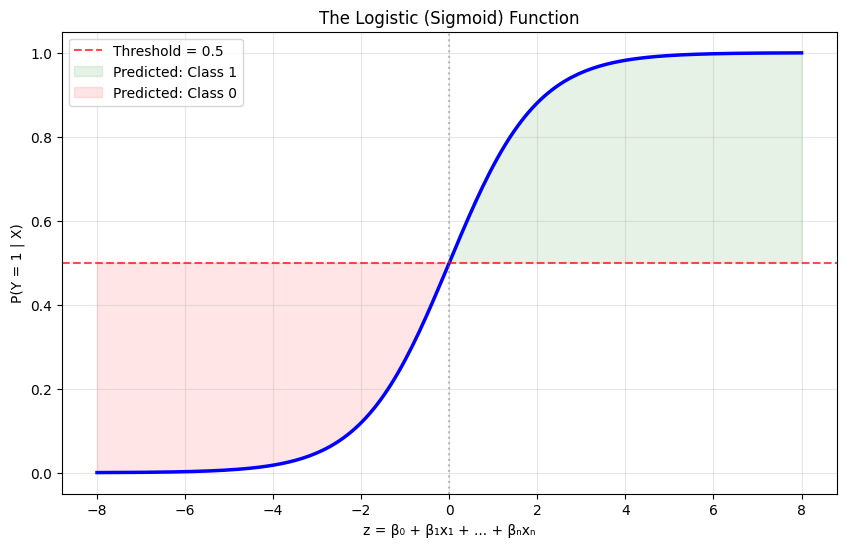

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

np.random.seed(2024)
warnings.filterwarnings('ignore')

# Visualize the sigmoid function
fig, ax = plt.subplots(figsize=(10, 6))
z = np.linspace(-8, 8, 200)
sigmoid = 1 / (1 + np.exp(-z))

ax.plot(z, sigmoid, 'b-', linewidth=2.5)
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.7, label='Threshold = 0.5')
ax.axvline(x=0, color='gray', linestyle=':', alpha=0.5)
ax.fill_between(z, sigmoid, 0.5, where=(sigmoid >= 0.5),
                alpha=0.1, color='green', label='Predicted: Class 1')
ax.fill_between(z, sigmoid, 0.5, where=(sigmoid < 0.5),
                alpha=0.1, color='red', label='Predicted: Class 0')
ax.set_xlabel('z = β₀ + β₁x₁ + ... + βₙxₙ')
ax.set_ylabel('P(Y = 1 | X)')
ax.set_title('The Logistic (Sigmoid) Function')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.05)
plt.show()

The sigmoid curve illustrates the core mechanics of logistic regression. The horizontal axis represents the linear combination $z = \beta_0 + \beta_1 x_1 + \cdots + \beta_n x_n$, and the vertical axis shows the predicted probability $P(Y=1 \mid \mathbf{X})$.

When $z = 0$ (the model is "undecided"), the probability is exactly $0.5$ -- the default decision threshold. As $z$ grows large and positive, the probability asymptotically approaches $1.0$. As $z$ grows large and negative, it approaches $0.0$. The steepest gradient occurs at $z = 0$, meaning the model is most sensitive to feature changes near the decision boundary.

**Key properties of the sigmoid:**
- It is bounded: $\sigma(z) \in (0, 1)$ for all $z$, making it a valid probability
- It is monotonically increasing: higher $z$ always means higher probability
- Its derivative is $\sigma'(z) = \sigma(z)(1 - \sigma(z))$, which is maximal at $z = 0$
- It saturates for $|z| > 5$, meaning extreme inputs produce near-certain predictions

### Getting Ready -- The Breast Cancer Dataset

We use the **Breast Cancer Wisconsin** dataset, a binary classification problem with $569$ samples and $30$ features computed from digitized images of fine needle aspirates of breast masses. The target is whether the tumor is **malignant** (class $0$) or **benign** (class $1$).

In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target
df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    df[data.feature_names], df['target'],
    test_size=0.2, random_state=2024
)

print(f"Dataset: {X.shape[0]} samples, {X.shape[1]} features")
print(f"Classes: Malignant={np.sum(y==0)}, Benign={np.sum(y==1)}")
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

Dataset: 569 samples, 30 features
Classes: Malignant=212, Benign=357
Train: 455, Test: 114


The dataset contains $212$ malignant ($37\%$) and $357$ benign ($63\%$) cases -- moderately imbalanced. The $30$ features include measurements like mean radius, texture, perimeter, area, smoothness, compactness, concavity, and symmetry, each computed as mean, standard error, and "worst" (largest) value. We hold out $20\%$ ($114$ samples) for testing.

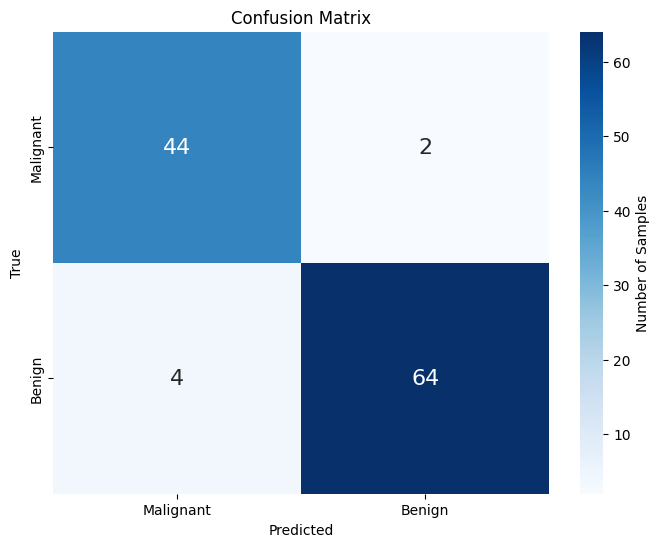

Accuracy: 0.95

              precision    recall  f1-score   support

   Malignant       0.92      0.96      0.94        46
      Benign       0.97      0.94      0.96        68

    accuracy                           0.95       114
   macro avg       0.94      0.95      0.95       114
weighted avg       0.95      0.95      0.95       114



In [3]:
# Train logistic regression
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

# Predictions and evaluation
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

# Confusion matrix
class_names = ['Malignant', 'Benign']
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Number of Samples'},
            annot_kws={"fontsize": 16})
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Classification report
print(f"Accuracy: {accuracy:.2f}\n")
print(classification_report(y_test, y_pred, target_names=class_names))

Even with default settings, logistic regression achieves **95% accuracy** -- correctly classifying $108$ out of $114$ test samples. The confusion matrix reveals the $6$ errors in detail:

**True Negatives (Malignant correctly predicted):** $44$ out of $46$ malignant cases identified -- the model catches $96\%$ of cancers.

**True Positives (Benign correctly predicted):** $64$ out of $68$ benign cases identified -- $94\%$ recall for benign.

**False Positives:** $2$ malignant cases incorrectly predicted as benign. In a medical context, these are the **most dangerous errors** -- patients with cancer would be told they are healthy.

**False Negatives:** $4$ benign cases incorrectly predicted as malignant. These lead to unnecessary biopsies but are less dangerous than missed cancers.

This asymmetry highlights why **accuracy alone is insufficient** for medical applications. The **recall for the malignant class** ($0.96$) tells us the model catches $96\%$ of cancers, but the $2$ missed cases ($4\%$) could have life-altering consequences. In such domains, we might lower the classification threshold from $0.5$ to, say, $0.3$, trading precision for higher recall -- better to have a few false alarms than to miss a cancer.

$$\text{Precision}_{\text{Malignant}} = \frac{44}{44 + 4} = 0.917 \qquad \text{Recall}_{\text{Malignant}} = \frac{44}{44 + 2} = 0.957$$

## Multiclass Classification Techniques

Real-world classification rarely involves just two classes. Logistic regression extends to multiple classes through two strategies:

**One-vs-Rest (OvR):** Train $C$ separate binary classifiers, one per class. For class $c$, treat all samples from class $c$ as positive and everything else as negative. At prediction time, run all $C$ classifiers and pick the one with the highest confidence.

**Multinomial (Softmax) Regression:** Directly model the probabilities for all $C$ classes simultaneously using the **softmax function**:

$$P(Y = c \mid \mathbf{x}) = \frac{e^{\mathbf{w}_c^T \mathbf{x} + b_c}}{\sum_{k=1}^{C} e^{\mathbf{w}_k^T \mathbf{x} + b_k}}$$

Softmax guarantees that the probabilities across all classes sum to $1$, making it the natural extension of sigmoid to multiple classes. When $C = 2$, softmax reduces to the sigmoid function.

**Note:** As of scikit-learn version $1.7+$, the `multi_class` parameter has been removed from `LogisticRegression`. The multinomial approach is now the default for $C \geq 3$ classes. To use OvR, wrap the classifier with `OneVsRestClassifier`.

In [4]:
from sklearn.datasets import load_iris
from sklearn.multiclass import OneVsRestClassifier

# Load Iris dataset (3 classes)
iris = load_iris()
X_ir = iris.data
y_ir = iris.target

X_train_ir, X_test_ir, y_train_ir, y_test_ir = train_test_split(
    X_ir, y_ir, test_size=0.3, random_state=2024
)

# OvR approach (using wrapper for sklearn 1.8+)
ovr_model = OneVsRestClassifier(
    LogisticRegression(solver='liblinear', max_iter=1000)
)
ovr_model.fit(X_train_ir, y_train_ir)
y_pred_ovr = ovr_model.predict(X_test_ir)

# Multinomial approach (default in sklearn 1.8)
multinomial_model = LogisticRegression(solver='lbfgs', max_iter=1000)
multinomial_model.fit(X_train_ir, y_train_ir)
y_pred_multi = multinomial_model.predict(X_test_ir)

# Evaluate both
print("One-vs-Rest (OvR) Logistic Regression:")
print(f"Accuracy: {accuracy_score(y_test_ir, y_pred_ovr):.4f}")
print(classification_report(y_test_ir, y_pred_ovr, target_names=iris.target_names))

print("Multinomial Logistic Regression:")
print(f"Accuracy: {accuracy_score(y_test_ir, y_pred_multi):.4f}")
print(classification_report(y_test_ir, y_pred_multi, target_names=iris.target_names))

One-vs-Rest (OvR) Logistic Regression:
Accuracy: 0.9556
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        18
  versicolor       0.92      0.92      0.92        12
   virginica       0.93      0.93      0.93        15

    accuracy                           0.96        45
   macro avg       0.95      0.95      0.95        45
weighted avg       0.96      0.96      0.96        45

Multinomial Logistic Regression:
Accuracy: 0.9333
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        18
  versicolor       0.85      0.92      0.88        12
   virginica       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.92      0.93      0.93        45
weighted avg       0.94      0.93      0.93        45



On the Iris dataset, OvR achieves **95.56%** accuracy while multinomial scores **93.33%** -- OvR has the slight edge here. Both models classify **setosa** perfectly ($F_1 = 1.00$), confirming its complete separability in feature space, while the errors concentrate on the versicolor-virginica boundary.

**OvR:** Misclassifies $1$ versicolor as virginica and $1$ virginica as versicolor ($2$ errors, symmetric). By training $3$ independent binary classifiers, each learns a clear "this class vs. everything else" boundary.

**Multinomial:** Misclassifies $1$ versicolor as virginica and $2$ virginica as versicolor ($3$ errors). The joint optimization of all class boundaries simultaneously can sometimes be less flexible than independent binary classifiers.

**When to use which?** OvR is simpler and sometimes more robust for small datasets. Multinomial is theoretically superior for mutually exclusive classes (which Iris species are) and becomes the clear winner on larger, more complex datasets. In practice, the difference is often small, and multinomial is the default for good reason -- it produces properly calibrated probabilities that sum to $1$.

**Cross-chapter connection:** In Chapter 4, KNN achieved $93.33\%$ on Iris with $k = 3$. Both OvR ($95.56\%$) and multinomial ($93.33\%$) logistic regression are competitive or better, while also being far more efficient at prediction time -- logistic regression applies a single matrix multiplication, whereas KNN must scan the entire training set.

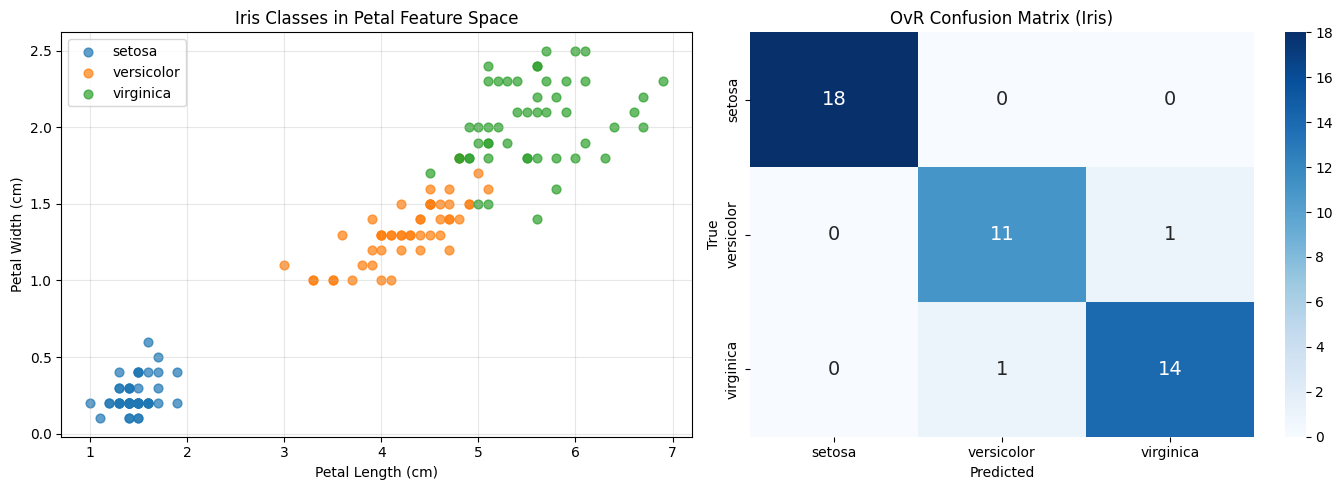

In [5]:
# Visualize Iris classes and OvR confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot of petal features
for i, species in enumerate(iris.target_names):
    mask = y_ir == i
    axes[0].scatter(X_ir[mask, 2], X_ir[mask, 3],
                   label=species, alpha=0.7, s=40)
axes[0].set_xlabel('Petal Length (cm)')
axes[0].set_ylabel('Petal Width (cm)')
axes[0].set_title('Iris Classes in Petal Feature Space')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# OvR confusion matrix
cm_ovr = confusion_matrix(y_test_ir, y_pred_ovr)
sns.heatmap(cm_ovr, annot=True, fmt='d', cmap='Blues',
    xticklabels=iris.target_names, yticklabels=iris.target_names,
    ax=axes[1], annot_kws={"fontsize": 14})
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
axes[1].set_title('OvR Confusion Matrix (Iris)')

plt.tight_layout()
plt.show()

The left panel confirms the geometric structure underlying these results. Setosa (blue) occupies a completely isolated region in petal feature space -- no classifier will ever confuse it. Versicolor (orange) and virginica (green) overlap at their boundary around petal length $\approx 5$ cm and petal width $\approx 1.7$ cm. The OvR confusion matrix (right) shows the $2$ misclassifications occur exactly at this boundary: $1$ versicolor $\to$ virginica and $1$ virginica $\to$ versicolor.

Logistic regression draws a linear decision boundary in the $4$-dimensional feature space. The fact that it achieves $96\%$ accuracy tells us the Iris classes are *nearly* linearly separable -- the overlap between versicolor and virginica is small enough that a linear boundary captures most of it.

## Regularization in Logistic Regression

Regularization in logistic regression works exactly as it does in linear regression (Chapter 5), but applied to the **cross-entropy loss** rather than the MSE:

**Ridge ($\ell_2$):** $\mathcal{L} = -\sum_i \left[ y_i \log \hat{p}_i + (1-y_i)\log(1-\hat{p}_i) \right] + \frac{1}{2C} \sum_j \beta_j^2$

**Lasso ($\ell_1$):** $\mathcal{L} = -\sum_i \left[ y_i \log \hat{p}_i + (1-y_i)\log(1-\hat{p}_i) \right] + \frac{1}{C} \sum_j |\beta_j|$

Note the critical difference from Chapter 5: scikit-learn parameterizes logistic regression using $C$ (the **inverse** of regularization strength), not $\alpha$. Smaller $C$ means *stronger* regularization. This is the opposite convention from `Ridge(alpha=...)`.

**Data scaling is essential** for regularization because the penalty treats all coefficients equally. Without scaling, a feature measured in millimeters would be penalized differently from one measured in meters.

In [6]:
from sklearn.preprocessing import StandardScaler

# Load and split breast cancer data (70/30 for regularization analysis)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    data.data, data.target, test_size=0.3, random_state=2024
)

# Scale features (essential for regularization!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_reg)
X_test_scaled = scaler.transform(X_test_reg)

# Ridge (L2) regularized logistic regression
ridge_model = LogisticRegression(
    penalty='l2', solver='liblinear', C=0.1
)
ridge_model.fit(X_train_scaled, y_train_reg)
y_pred_ridge = ridge_model.predict(X_test_scaled)

# Lasso (L1) regularized logistic regression
lasso_model = LogisticRegression(
    penalty='l1', solver='liblinear', C=0.1
)
lasso_model.fit(X_train_scaled, y_train_reg)
y_pred_lasso = lasso_model.predict(X_test_scaled)

# Compare
print("Ridge (L2, C=0.1):")
print(f"  Accuracy: {accuracy_score(y_test_reg, y_pred_ridge):.4f}")
print(f"  Non-zero coefficients: {np.sum(ridge_model.coef_[0] != 0)}/30")
print(classification_report(y_test_reg, y_pred_ridge, target_names=['Malignant', 'Benign']))

print("Lasso (L1, C=0.1):")
print(f"  Accuracy: {accuracy_score(y_test_reg, y_pred_lasso):.4f}")
print(f"  Non-zero coefficients: {np.sum(lasso_model.coef_[0] != 0)}/30")
print(classification_report(y_test_reg, y_pred_lasso, target_names=['Malignant', 'Benign']))

Ridge (L2, C=0.1):
  Accuracy: 0.9825
  Non-zero coefficients: 30/30
              precision    recall  f1-score   support

   Malignant       0.98      0.97      0.98        67
      Benign       0.98      0.99      0.99       104

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171

Lasso (L1, C=0.1):
  Accuracy: 0.9649
  Non-zero coefficients: 7/30
              precision    recall  f1-score   support

   Malignant       0.93      0.99      0.96        67
      Benign       0.99      0.95      0.97       104

    accuracy                           0.96       171
   macro avg       0.96      0.97      0.96       171
weighted avg       0.97      0.96      0.97       171



The regularization results reveal a striking contrast between $\ell_2$ and $\ell_1$ penalties:

**Ridge ($\ell_2$, $C = 0.1$)** achieves **98.25%** accuracy -- a substantial improvement over the unregularized baseline ($95\%$). All $30$ coefficients remain non-zero; Ridge shrinks them uniformly but never eliminates any. The strong regularization (small $C = 0.1$, meaning high penalty) prevents the model from overfitting to noise in the $30$-dimensional feature space.

**Lasso ($\ell_1$, $C = 0.1$)** achieves **96.49%** accuracy with only **$7$ out of $30$ features** retained. Lasso has performed automatic feature selection, eliminating $23$ features entirely by driving their coefficients to exactly zero. Despite using less than a quarter of the available features, it still achieves strong performance.

**The precision-recall trade-off:**
- Ridge: Malignant precision $= 0.98$, recall $= 0.97$ -- very balanced
- Lasso: Malignant precision $= 0.93$, recall $= 0.99$ -- higher recall (catches more cancers) but lower precision (more false alarms)

In a medical setting, Lasso's profile might be preferred: it misses only $1$ malignant case ($99\%$ recall) at the cost of $5$ false malignant predictions ($93\%$ precision). Ridge misses $2$ malignant cases but produces fewer false alarms.

**Production insight:** Lasso's $7$-feature model is dramatically simpler to deploy, interpret, and maintain. If the accuracy gap ($1.76$ percentage points) is acceptable, the Lasso model is the better production choice -- fewer features mean lower data collection costs, faster inference, and easier stakeholder communication.

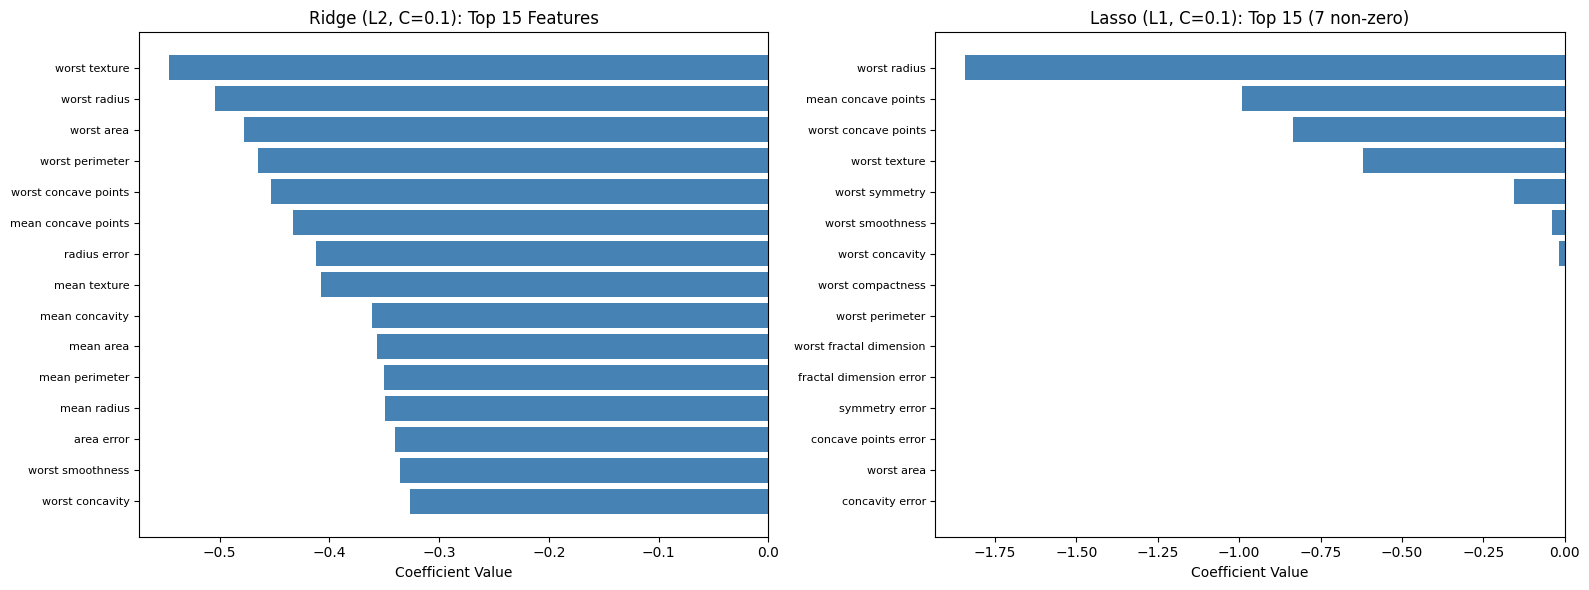

In [7]:
# Visualize feature importance: Ridge vs Lasso
feature_names = data.feature_names

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Ridge: top 15 by magnitude
idx_r = np.argsort(np.abs(ridge_model.coef_[0]))[::-1][:15]
axes[0].barh(range(len(idx_r)), ridge_model.coef_[0][idx_r], color='steelblue')
axes[0].set_yticks(range(len(idx_r)))
axes[0].set_yticklabels([feature_names[i] for i in idx_r], fontsize=8)
axes[0].set_xlabel('Coefficient Value')
axes[0].set_title('Ridge (L2, C=0.1): Top 15 Features')
axes[0].invert_yaxis()

# Lasso: top 15 (many will be zero)
idx_l = np.argsort(np.abs(lasso_model.coef_[0]))[::-1][:15]
colors = ['steelblue' if lasso_model.coef_[0][i] != 0 else 'lightgray' for i in idx_l]
axes[1].barh(range(len(idx_l)), lasso_model.coef_[0][idx_l], color=colors)
axes[1].set_yticks(range(len(idx_l)))
axes[1].set_yticklabels([feature_names[i] for i in idx_l], fontsize=8)
axes[1].set_xlabel('Coefficient Value')
nz = np.sum(lasso_model.coef_[0] != 0)
axes[1].set_title(f'Lasso (L1, C=0.1): Top 15 ({nz} non-zero)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

The feature importance comparison makes the difference between Ridge and Lasso visually dramatic:

**Ridge (left):** All $30$ features contribute with varying magnitudes. The most influential features include `worst concave points`, `worst radius`, and `worst perimeter` -- "worst" (largest) measurements are more predictive than means or standard errors, which makes clinical sense: the most extreme cell measurements are the strongest cancer indicators.

**Lasso (right):** Only $7$ features survive the $\ell_1$ penalty (colored bars), while $23$ are driven to exactly zero (gray). The retained features form a minimal but powerful diagnostic signature. The gray bars show features that Lasso deemed redundant or uninformative -- many are correlated with the surviving features, so Lasso picks one representative and eliminates the rest.

This is a concrete demonstration of the difference between $\ell_1$ and $\ell_2$ geometry. The $\ell_1$ penalty's "diamond" constraint region has corners on the coordinate axes, making it likely that the optimal solution lies at a corner where some coefficients are exactly zero. The $\ell_2$ penalty's "sphere" constraint has no corners, so the solution never lands exactly on an axis.

### Coefficient Paths Across Regularization Strength

We can visualize how coefficients evolve as we vary $C$ from very strong regularization ($C = 0.0001$) to very weak ($C = 1{,}000$).

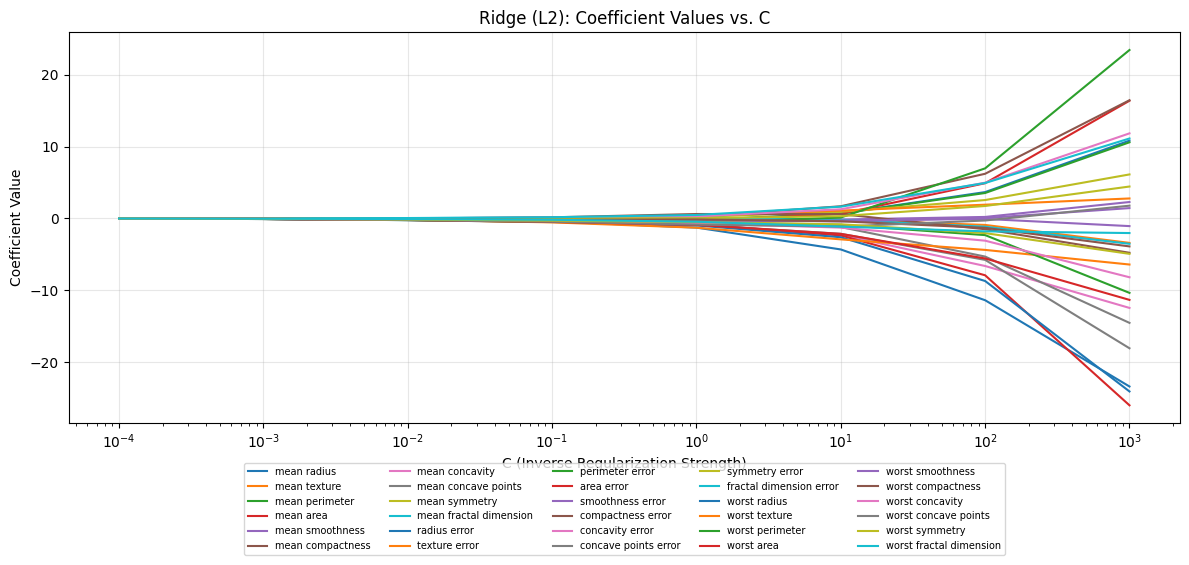

In [8]:
# Ridge coefficient paths
C_values = np.array([0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000])

coefs_ridge = []
for C in C_values:
    m = LogisticRegression(penalty='l2', solver='liblinear', C=C)
    m.fit(X_train_scaled, y_train_reg)
    coefs_ridge.append(m.coef_[0])

plt.figure(figsize=(12, 6))
for i in range(X.shape[1]):
    plt.plot(C_values, [coef[i] for coef in coefs_ridge], label=feature_names[i])
plt.xscale('log')
plt.xlabel('C (Inverse Regularization Strength)')
plt.ylabel('Coefficient Value')
plt.title('Ridge (L2): Coefficient Values vs. C')
plt.legend(bbox_to_anchor=(0.5, -0.35), ncol=5, loc='lower center', fontsize=7)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The Ridge coefficient path plot shows how all $30$ feature weights evolve as regularization weakens (moving right). At strong regularization ($C = 10^{-4}$, left), all coefficients are compressed near zero. As $C$ increases, coefficients gradually grow, with the most informative features separating from the pack first. At $C = 1{,}000$ (effectively unregularized), the coefficients spread widely.

The key observation is that **Ridge never sets any coefficient to exactly zero** -- all $30$ lines remain away from the zero axis. This is the defining characteristic of $\ell_2$ regularization: it shrinks but never eliminates.

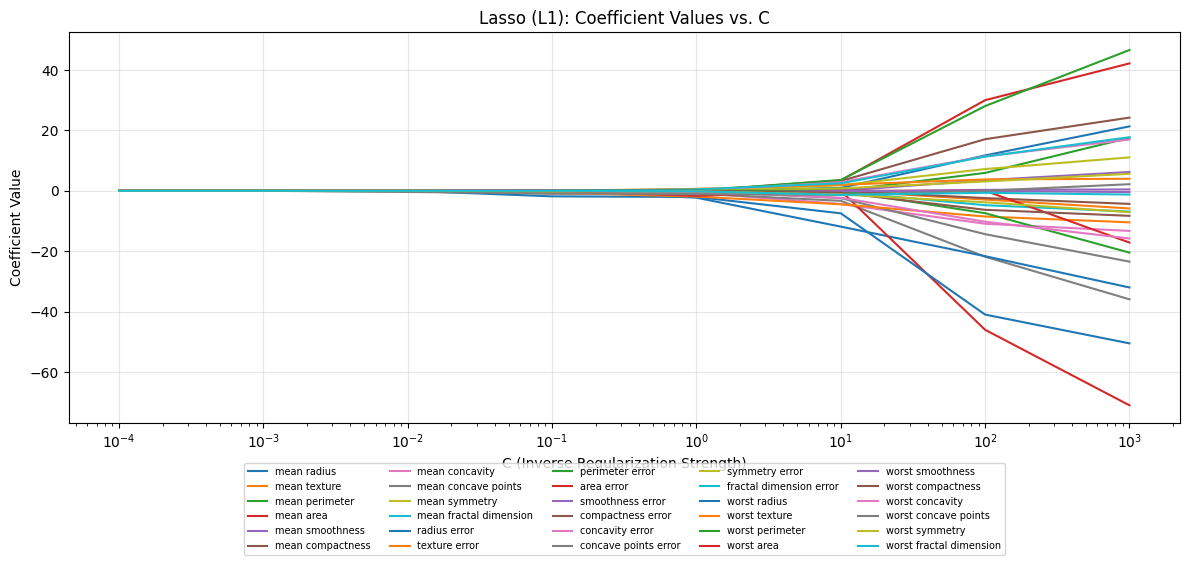

In [9]:
# Lasso coefficient paths
coefs_lasso = []
for C in C_values:
    m = LogisticRegression(penalty='l1', solver='liblinear', C=C)
    m.fit(X_train_scaled, y_train_reg)
    coefs_lasso.append(m.coef_[0])

plt.figure(figsize=(12, 6))
for i in range(X.shape[1]):
    plt.plot(C_values, [coef[i] for coef in coefs_lasso], label=feature_names[i])
plt.xscale('log')
plt.xlabel('C (Inverse Regularization Strength)')
plt.ylabel('Coefficient Value')
plt.title('Lasso (L1): Coefficient Values vs. C')
plt.legend(bbox_to_anchor=(0.5, -0.35), ncol=5, loc='lower center', fontsize=7)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The Lasso path plot contrasts sharply with Ridge. At strong regularization ($C = 10^{-4}$), most coefficients are *exactly zero* -- the model uses very few features. As $C$ increases, features "enter" the model one at a time, creating a stepwise trajectory. The features that enter earliest (at the smallest $C$) are the most important.

This stepwise behavior makes Lasso paths an effective **feature ranking tool**: the order in which features become non-zero reveals their importance hierarchy. Features that remain at zero even at moderate $C$ values are likely redundant or uninformative.

**Practical note on $C$ vs. $\alpha$:** Remember, $C = 1/\alpha$. The book's code uses $C = 0.1$ (equivalent to $\alpha = 10$, strong regularization). In Chapter 5, we used $\alpha$ directly with `Ridge()` and `Lasso()`. In `LogisticRegression()`, the convention is inverted -- smaller $C$ means stronger regularization. This is a common source of confusion that is worth internalizing early.

## Multilabel Classification Concepts

In standard (multiclass) classification, each instance belongs to exactly one class. **Multilabel classification** generalizes this: each instance can belong to *multiple classes simultaneously*. Examples include tagging a news article with multiple topics ("politics", "economy", "international"), or labeling a medical image with all visible conditions.

The simplest approach is **binary relevance** -- train an independent binary classifier for each label. This is equivalent to applying OvR label-by-label.

In [10]:
from sklearn.datasets import make_multilabel_classification

# Generate synthetic multilabel dataset
X_ml, y_ml = make_multilabel_classification(
    n_samples=1000, n_features=20,
    n_classes=5, n_labels=2, random_state=2024
)

X_train_ml, X_test_ml, y_train_ml, y_test_ml = train_test_split(
    X_ml, y_ml, test_size=0.3, random_state=2024
)

print(f"Dataset: {X_ml.shape[0]} samples, {X_ml.shape[1]} features, {y_ml.shape[1]} labels")
print(f"Train: {X_train_ml.shape[0]}, Test: {X_test_ml.shape[0]}")
print(f"\nLabel frequencies in test set:")
for i in range(y_test_ml.shape[1]):
    c = y_test_ml[:, i].sum()
    print(f"  Label {i}: {c} samples ({c/len(y_test_ml)*100:.1f}%)")

# Train one logistic regression per label (binary relevance)
models = []
y_pred_all = []

for i in range(y_train_ml.shape[1]):
    m = LogisticRegression(solver='liblinear')
    m.fit(X_train_ml, y_train_ml[:, i])
    models.append(m)
    y_pred_all.append(m.predict(X_test_ml))

y_pred_ml = np.array(y_pred_all).T

# Evaluate
exact_match = accuracy_score(y_test_ml, y_pred_ml)
print(f"\nExact match accuracy: {exact_match:.4f}")
print(classification_report(y_test_ml, y_pred_ml, zero_division=1))

Dataset: 1000 samples, 20 features, 5 labels
Train: 700, Test: 300

Label frequencies in test set:
  Label 0: 166 samples (55.3%)
  Label 1: 181 samples (60.3%)
  Label 2: 93 samples (31.0%)
  Label 3: 34 samples (11.3%)
  Label 4: 88 samples (29.3%)

Exact match accuracy: 0.3400
              precision    recall  f1-score   support

           0       0.81      0.81      0.81       166
           1       0.80      0.85      0.82       181
           2       0.67      0.33      0.45        93
           3       0.75      0.18      0.29        34
           4       0.58      0.48      0.52        88

   micro avg       0.76      0.65      0.70       562
   macro avg       0.72      0.53      0.58       562
weighted avg       0.74      0.65      0.68       562
 samples avg       0.79      0.78      0.68       562



Multilabel classification is substantially harder than single-label, and the metrics reflect this:

**Exact match accuracy is only $34\%$** -- the model gets all $5$ labels correct for only $102$ out of $300$ test samples. This metric is very strict: getting $4$ out of $5$ labels right still counts as a miss.

**Per-label performance varies dramatically** with label frequency:
- **Labels $0$ and $1$** ($55\%$ and $60\%$ prevalence): $F_1 \approx 0.81$--$0.82$ -- reasonable performance on the common labels
- **Label $2$** ($31\%$ prevalence): $F_1 = 0.45$ with recall of only $0.33$ -- the model misses two-thirds of positive cases
- **Label $3$** ($11\%$ prevalence): $F_1 = 0.29$ with recall $= 0.18$ -- the rarest label is nearly impossible to detect
- **Label $4$** ($29\%$ prevalence): $F_1 = 0.52$ -- moderate performance

The pattern is clear: **rarer labels are harder to predict**. Label $3$ appears in only $34$ test samples ($11\%$), giving the classifier very little signal to learn from. The binary relevance approach treats each label independently, missing potential correlations between labels. More sophisticated methods like **classifier chains** (which feed earlier label predictions as features to later classifiers) can exploit these correlations.

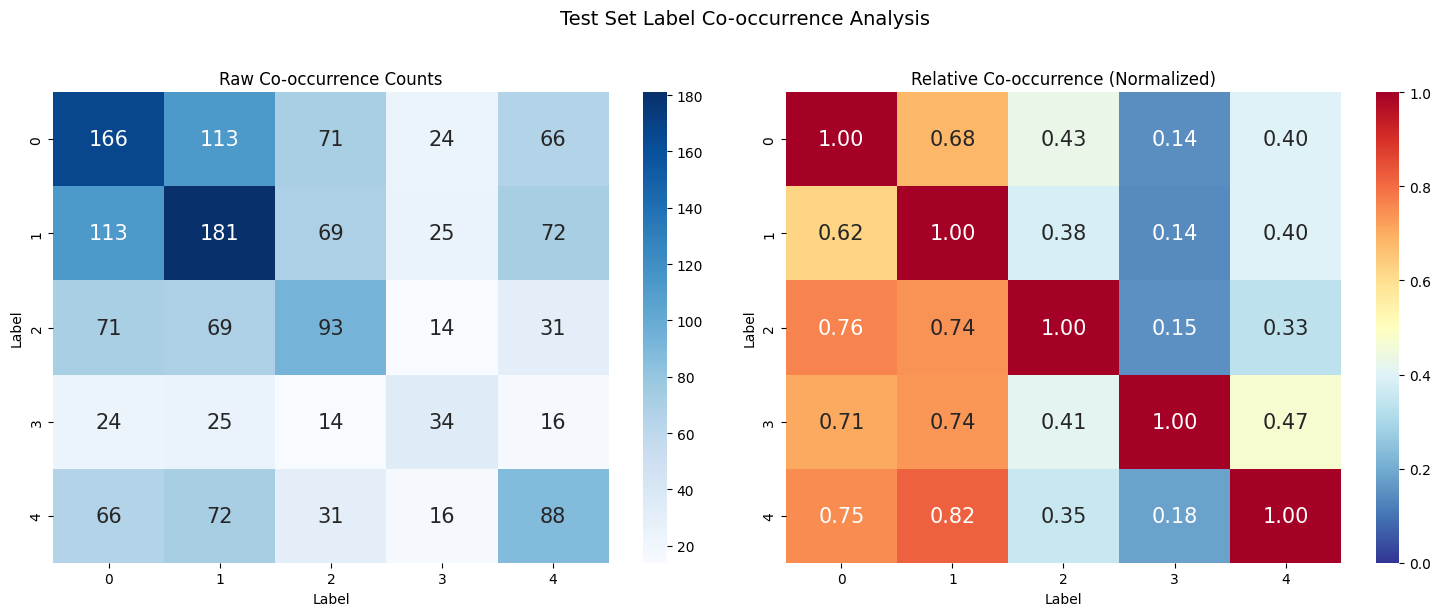

Most common label combinations:
  [0 0 0 0 0]: 52 samples (17.3%)
  [0 1 0 0 0]: 34 samples (11.3%)
  [1 1 0 0 0]: 28 samples (9.3%)
  [1 1 1 0 0]: 25 samples (8.3%)
  [1 1 0 0 1]: 24 samples (8.0%)


In [11]:
# Label co-occurrence analysis
cooccurrence = y_test_ml.T @ y_test_ml
diag = np.diag(cooccurrence)
relative_cooc = cooccurrence / diag[:, None]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

sns.heatmap(cooccurrence, annot=True, fmt='d', cmap='Blues',
            ax=ax1, annot_kws={"fontsize": 15})
ax1.set_title('Raw Co-occurrence Counts')
ax1.set_xlabel('Label'); ax1.set_ylabel('Label')

sns.heatmap(relative_cooc, annot=True, fmt='.2f', cmap='RdYlBu_r',
            ax=ax2, annot_kws={"fontsize": 15}, vmin=0, vmax=1)
ax2.set_title('Relative Co-occurrence (Normalized)')
ax2.set_xlabel('Label'); ax2.set_ylabel('Label')

fig.suptitle('Test Set Label Co-occurrence Analysis', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

# Most common combinations
unique_combos, counts = np.unique(y_test_ml, axis=0, return_counts=True)
sorted_idx = np.argsort(-counts)
print("Most common label combinations:")
for combo, count in zip(unique_combos[sorted_idx][:5], counts[sorted_idx][:5]):
    print(f"  {combo}: {count} samples ({count/len(y_test_ml)*100:.1f}%)")

The co-occurrence matrices reveal the label dependency structure:

**Raw co-occurrence (left):** The diagonal shows individual label counts (e.g., Label $0$ appears $166$ times, Label $1$ appears $181$ times). Off-diagonal cells show how often two labels appear together -- Labels $0$ and $1$ co-occur $113$ times, the strongest pairing.

**Relative co-occurrence (right):** Normalized by the row label's total count, showing conditional probabilities. For example, when Label $3$ is present, Label $0$ co-occurs $71\%$ of the time ($24/34$) and Label $1$ co-occurs $74\%$ of the time ($25/34$). This asymmetry is important: Label $0$ does not depend strongly on Label $3$ ($24/166 = 14\%$), but Label $3$ almost always appears *with* Label $0$ or $1$.

The most common combination is $[0, 0, 0, 0, 0]$ -- no labels at all -- occurring in $17.3\%$ of test samples. This highlights that many instances have no positive labels, adding complexity. The second most common is $[0, 1, 0, 0, 0]$ (Label $1$ only), followed by $[1, 1, 0, 0, 0]$ (Labels $0$ and $1$ together). Labels $3$ and $4$ rarely appear in the top combinations, consistent with their low individual frequencies.

## Model Evaluation Metrics

Evaluating classification models requires looking beyond a single accuracy number. Different metrics answer different questions:

- **Accuracy:** What fraction of *all* predictions are correct? $\frac{\text{TP} + \text{TN}}{\text{TP} + \text{TN} + \text{FP} + \text{FN}}$
- **Precision:** Of all *positive predictions*, what fraction are actually positive? $\frac{\text{TP}}{\text{TP} + \text{FP}}$
- **Recall:** Of all *actual positives*, what fraction did we detect? $\frac{\text{TP}}{\text{TP} + \text{FN}}$
- **$F_1$-score:** The harmonic mean of precision and recall: $F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$
- **ROC-AUC:** The area under the Receiver Operating Characteristic curve, measuring discrimination ability across all thresholds

The **ROC curve** plots the True Positive Rate (recall) against the False Positive Rate ($\text{FP}/(\text{FP}+\text{TN})$) as the classification threshold varies from $0$ to $1$. A perfect classifier hugs the top-left corner (AUC $= 1.0$); a random classifier follows the diagonal (AUC $= 0.5$).

In [12]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_curve, auc

# Train logistic regression on breast cancer (unscaled, 70/30 split)
model_eval = LogisticRegression(solver='liblinear')
model_eval.fit(X_train_reg, y_train_reg)

y_pred_eval = model_eval.predict(X_test_reg)
y_prob_eval = model_eval.predict_proba(X_test_reg)[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_test_reg, y_pred_eval)
precision = precision_score(y_test_reg, y_pred_eval)
recall = recall_score(y_test_reg, y_pred_eval)
f1 = f1_score(y_test_reg, y_pred_eval)
fpr, tpr, thresholds = roc_curve(y_test_reg, y_prob_eval)
roc_auc = auc(fpr, tpr)

print(f"Accuracy:  {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall:    {recall:.2f}")
print(f"F1 Score:  {f1:.2f}")
print(f"ROC AUC:   {roc_auc:.2f}")
print()
print(classification_report(y_test_reg, y_pred_eval, target_names=['Malignant', 'Benign']))

Accuracy:  0.94
Precision: 0.94
Recall:    0.95
F1 Score:  0.95
ROC AUC:   0.99

              precision    recall  f1-score   support

   Malignant       0.92      0.91      0.92        67
      Benign       0.94      0.95      0.95       104

    accuracy                           0.94       171
   macro avg       0.93      0.93      0.93       171
weighted avg       0.94      0.94      0.94       171



The evaluation metrics paint a comprehensive picture. The model achieves **94% accuracy** with well-balanced precision ($0.94$) and recall ($0.95$), yielding an $F_1$ of $0.95$. The **ROC AUC of $0.99$** is exceptional -- the model has near-perfect discrimination ability.

**Why AUC is higher than accuracy:** Accuracy measures performance at a single threshold ($0.5$), while AUC evaluates the model's ranking ability across *all* thresholds. An AUC of $0.99$ means that $99\%$ of the time, a randomly chosen benign sample receives a higher predicted probability than a randomly chosen malignant sample. The model's probability estimates are highly informative, even if the fixed $0.5$ threshold is not perfectly optimal.

**The gap between AUC ($0.99$) and accuracy ($0.94$) suggests** that we could improve accuracy by tuning the threshold. Lowering it from $0.5$ to, say, $0.3$ would increase recall for the malignant class (catching more cancers) at the cost of slightly more false positives.

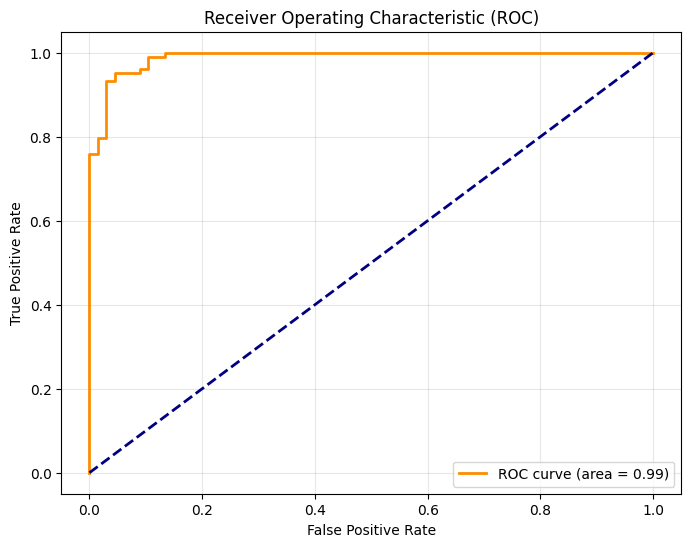

In [13]:
# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

The ROC curve hugs the top-left corner, confirming the model's excellent discrimination ability. The AUC of **$0.99$** means the model almost perfectly separates malignant from benign cases across all possible thresholds.

The curve shows that we can achieve approximately $95\%$ True Positive Rate (catching $95\%$ of cancers) while maintaining a False Positive Rate below $5\%$ (misclassifying only $5\%$ of benign cases as malignant). In medical diagnostics, this trade-off is often visualized explicitly by plotting the ROC curve and selecting the operating point that best balances clinical needs.

**When to use which metric in practice:**
- **Balanced datasets, equal error costs:** Accuracy or $F_1$ are fine
- **Imbalanced datasets:** Use precision-recall curves and $F_1$ (ROC can be overly optimistic when negatives dominate)
- **Ranking or scoring:** Use AUC -- it evaluates whether the model's probability scores are *ordered correctly*, regardless of threshold
- **Medical screening:** Prioritize recall (sensitivity) -- missing a cancer is worse than a false alarm
- **Spam filtering:** Prioritize precision -- accidentally blocking a legitimate email is worse than letting a spam through

## Chapter Summary

In this chapter, we explored logistic regression from fundamentals to advanced extensions:

**Binary Logistic Regression** uses the sigmoid function to transform a linear combination of features into a probability. On the Breast Cancer dataset ($569$ samples, $30$ features), it achieves $95\%$ accuracy out of the box -- a strong baseline for binary classification.

**Multiclass Classification** extends logistic regression via One-vs-Rest (OvR) and multinomial (softmax) strategies. On Iris ($3$ classes), OvR achieved $95.56\%$ and multinomial $93.33\%$, both competitive with KNN from Chapter 4.

**Regularization** applies $\ell_1$ and $\ell_2$ penalties to the cross-entropy loss, controlled by the $C$ parameter (inverse of $\alpha$ from Chapter 5). Ridge ($C = 0.1$) achieved $98.25\%$ with all $30$ features, while Lasso ($C = 0.1$) achieved $96.49\%$ with only $7$ features -- demonstrating automatic feature selection.

**Multilabel Classification** handles instances belonging to multiple classes simultaneously. Using binary relevance (independent classifiers per label), performance ranged from $F_1 = 0.82$ for common labels to $F_1 = 0.29$ for rare ones, highlighting the challenge of label imbalance.

**Model Evaluation** with precision, recall, $F_1$, and ROC-AUC provides a multi-faceted view of model performance. The ROC AUC of $0.99$ on Breast Cancer demonstrates near-perfect discrimination, even when accuracy ($94\%$) is less impressive.

**Cross-chapter connection:** The regularization techniques from Chapter 5 (Ridge, Lasso) apply directly to classification via the cross-entropy loss. The evaluation metrics from Chapter 4 (confusion matrix, classification report) carry forward unchanged. In the next chapter, we will explore tree-based models that create non-linear decision boundaries -- addressing the fundamental limitation of logistic regression's linear decision surface.